<a href="https://colab.research.google.com/github/RhugvedChavan/Acute-Heart-Disease-Prediction-Model-/blob/main/Acute_Heart_Disease_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<font color='red'>**Acute Heart Disease (AHD) Case study**

Every day, the average human heart beats around 100,000 times, pumping 2,000 gallons of blood through the body. Inside your body there are 60,000 miles of blood vessels.


The signs of a woman having a heart attack are much less noticeable than the signs of a male. In women, heart attacks may feel uncomfortable squeezing, pressure, fullness, or pain in the center of the chest. It may also cause pain in one or both arms, the back, neck, jaw or stomach, shortness of breath, nausea and other symptoms. Men experience typical symptoms of heart attack, such as chest pain , discomfort, and stress. They may also experience pain in other areas, such as arms, neck , back, and jaw, and shortness of breath, sweating, and discomfort that mimics heartburn.


It’s a lot of work for an organ which is just like a large fist and weighs between 8 and 12 ounces.

source: healthblog.uofmhealth

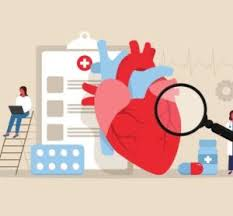




**Problem Statement:** Using heart dataset,trying to predict if someone will get Acute heart disease(AHD) with other health parameter

<font color='blue'>**Dataset columns:**

**age:** The person’s age in years

**sex:** The person’s sex (1 = male, 0 = female)

**cp:** chest pain type
*   Value 0: asymptomatic
*   Value 1: atypical angina
*   Value 2: non-anginal pain
*   Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)

**RestECG:** resting electrocardiographic results
*   Value 0: showing probable or definite left ventricular hypertrophy by Estes’
*   Value 1: normal
*   Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**MaxHR:** The person’s maximum heart rate achieved

**ExAng:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia
*   Value 0: NULL (dropped from the dataset previously
*   Value 1: fixed defect (no blood flow in some part of the heart)
*   Value 2: normal blood flow
*   Value 3: reversible defect (a blood flow is observed but it is not normal)

**AHD:** Heart disease (1 = no, 0= yes)



---



In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read file Hearts.csv
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/Heart.csv')
df

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [ ]:
# display columns of dataset
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs',
       'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD'],
      dtype='object')

In [ ]:
# display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    int64  
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    object 
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    object 
 14  AHD         303 non-null    object 
dtypes: float64(2), int64(10), object(3)
memory usage: 35.6+ KB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0


In [ ]:
df.Ca.unique()

array([ 0.,  3.,  2.,  1., nan])

In [ ]:
df.Thal.unique()

array(['fixed', 'normal', 'reversable', nan], dtype=object)

In [ ]:
#describe details of object type columns
df.describe(include='O')

,ChestPain,Thal,AHD
count,303,301,303
unique,4,3,2
top,asymptomatic,normal,No
freq,144,166,164


In [ ]:
df.ChestPain.value_counts()

,count
ChestPain,
asymptomatic,144
nonanginal,86
nontypical,50
typical,23


In [ ]:
df.ChestPain.value_counts().index[0]

'asymptomatic'

In [ ]:
df.describe()

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,152.000000,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,87.612784,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,1.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,76.500000,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,152.000000,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,227.500000,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,303.000000,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [ ]:
#describe details of numeric type columns
df.describe(exclude='O')

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,152.000000,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,87.612784,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,1.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,76.500000,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,152.000000,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,227.500000,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,303.000000,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [ ]:
#display rows and columns of dataset
df.shape

(303, 15)

In [ ]:
print("Number of rows in dataset: ",df.shape[0])

Number of rows in dataset:  303


In [ ]:
print("Number of Columns in the dataset: ",df.shape[1])

Number of Columns in the dataset:  15


##<font color='green'>**Feature Engineering**

In [ ]:
#check null value columns
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0


In [ ]:
# displau unique values from Thal column
df.Thal.unique()

array(['fixed', 'normal', 'reversable', nan], dtype=object)

In [ ]:
# Display Thal column wise count of records
df.Thal.value_counts()

,count
Thal,
normal,166
reversable,117
fixed,18


In [ ]:
df.Thal.value_counts()

,count
Thal,
normal,166
reversable,117
fixed,18


In [ ]:
# Display Thal column wise count of records
df.Thal.value_counts().index[0]

'normal'

In [ ]:
df.Thal.unique()

array(['fixed', 'normal', 'reversable', nan], dtype=object)

In [ ]:
# As the maximum number of cases have 'normal' as the Thal,
# replacing the missing value to 'normal'
df.Thal = df.Thal.fillna(df.Thal.value_counts().index[0])
df.Thal.value_counts()

,count
Thal,
normal,168
reversable,117
fixed,18


In [ ]:
#crossverify the Thal column -> are there any null values?
df.Thal.isnull().sum()

np.int64(0)

In [ ]:
df.Ca.unique()

array([ 0.,  3.,  2.,  1., nan])

In [ ]:
# display number of vessels
df.Ca.value_counts()

,count
Ca,
0.0,176
1.0,65
2.0,38
3.0,20


In [ ]:
df.Ca.value_counts().index

Index([0.0, 1.0, 2.0, 3.0], dtype='float64', name='Ca')

In [ ]:
df.Ca.value_counts().index[0]

np.float64(0.0)

In [ ]:
# As the maximum number of cases have 0.0 as the Ca,
# replacing the missing value to 0.0
df.Ca = df.Ca.fillna(df.Ca.value_counts().index[0])
df.Ca.value_counts()

,count
Ca,
0.0,180
1.0,65
2.0,38
3.0,20


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0


In [ ]:
# Display/print unique values from columns ChestPain, Thal and AHD
print(df.ChestPain.unique())
print(df.Thal.unique())
print(df.AHD.unique())

['typical' 'asymptomatic' 'nonanginal' 'nontypical']
['fixed' 'normal' 'reversable']
['No' 'Yes']


In [ ]:
#nominal encoding technique
df_encoding = pd.get_dummies(df[['ChestPain', 'Thal', 'AHD']])
df_encoding

,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable,AHD_No,AHD_Yes
0,False,False,False,True,True,False,False,True,False
1,True,False,False,False,False,True,False,False,True
2,True,False,False,False,False,False,True,False,True
3,False,True,False,False,False,True,False,True,False
4,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...
298,False,False,False,True,False,False,True,False,True
299,True,False,False,False,False,False,True,False,True
300,True,False,False,False,False,False,True,False,True
301,False,False,True,False,False,True,False,False,True


In [ ]:
df.ChestPain.unique()

array(['typical', 'asymptomatic', 'nonanginal', 'nontypical'],
      dtype=object)

In [ ]:
df.Thal.unique()

array(['fixed', 'normal', 'reversable'], dtype=object)

In [ ]:
df_encoding.columns

Index(['ChestPain_asymptomatic', 'ChestPain_nonanginal',
       'ChestPain_nontypical', 'ChestPain_typical', 'Thal_fixed',
       'Thal_normal', 'Thal_reversable', 'AHD_No', 'AHD_Yes'],
      dtype='object')

In [ ]:
df_final = pd.concat([df, df_encoding],axis=1)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              303 non-null    int64  
 1   Age                     303 non-null    int64  
 2   Sex                     303 non-null    int64  
 3   ChestPain               303 non-null    object 
 4   RestBP                  303 non-null    int64  
 5   Chol                    303 non-null    int64  
 6   Fbs                     303 non-null    int64  
 7   RestECG                 303 non-null    int64  
 8   MaxHR                   303 non-null    int64  
 9   ExAng                   303 non-null    int64  
 10  Oldpeak                 303 non-null    float64
 11  Slope                   303 non-null    int64  
 12  Ca                      303 non-null    float64
 13  Thal                    303 non-null    object 
 14  AHD                     303 non-null    ob

In [ ]:
df_final.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs',
       'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD',
       'ChestPain_asymptomatic', 'ChestPain_nonanginal',
       'ChestPain_nontypical', 'ChestPain_typical', 'Thal_fixed',
       'Thal_normal', 'Thal_reversable', 'AHD_No', 'AHD_Yes'],
      dtype='object')

In [ ]:
df_final = df_final.drop(['Unnamed: 0','ChestPain', 'Thal','AHD'], axis = 1)
df_final

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable,AHD_No,AHD_Yes
0,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,False,True,True,False,False,True,False
1,67,1,160,286,0,2,108,1,1.5,2,3.0,True,False,False,False,False,True,False,False,True
2,67,1,120,229,0,2,129,1,2.6,2,2.0,True,False,False,False,False,False,True,False,True
3,37,1,130,250,0,0,187,0,3.5,3,0.0,False,True,False,False,False,True,False,True,False
4,41,0,130,204,0,2,172,0,1.4,1,0.0,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,110,264,0,0,132,0,1.2,2,0.0,False,False,False,True,False,False,True,False,True
299,68,1,144,193,1,0,141,0,3.4,2,2.0,True,False,False,False,False,False,True,False,True
300,57,1,130,131,0,0,115,1,1.2,2,1.0,True,False,False,False,False,False,True,False,True
301,57,0,130,236,0,2,174,0,0.0,2,1.0,False,False,True,False,False,True,False,False,True


In [ ]:
#display columns from df_final
df_final.columns

Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_asymptomatic',
       'ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical',
       'Thal_fixed', 'Thal_normal', 'Thal_reversable', 'AHD_No', 'AHD_Yes'],
      dtype='object')

In [ ]:
# checking no. of males(1) and female (0)
df_final.Sex.value_counts()

,count
Sex,
1,206
0,97


In [ ]:
# display crosstab report of Acute Heart Dieses (Yes) and sex (0: female, 1:male)
ct=pd.crosstab(df_final.AHD_Yes, df_final.Sex)
ct

Sex,0,1
AHD_Yes,,
False,72,92
True,25,114


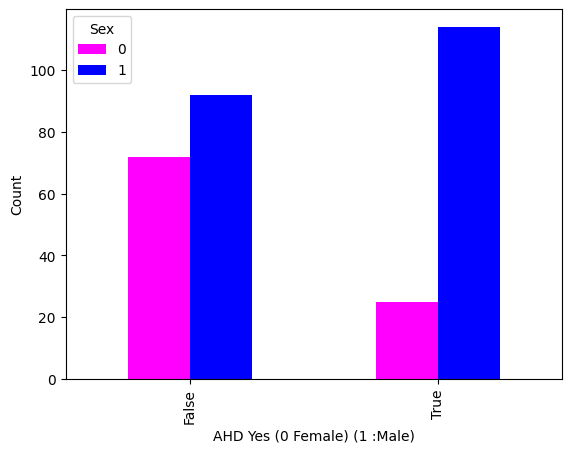

In [ ]:
ct.plot(kind='bar',color=['magenta','blue'])
plt.xlabel("AHD Yes (0 Female) (1 :Male)")
plt.ylabel("Count")
plt.show()

In [ ]:
df_final.AHD_Yes.value_counts()

,count
AHD_Yes,
False,164
True,139


In [ ]:
df_final.AHD_Yes.unique()

array([False,  True])

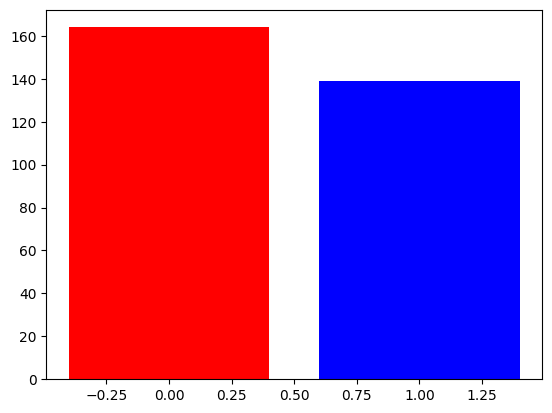

In [ ]:
plt.bar(df_final.AHD_Yes.unique(),df_final.AHD_Yes.value_counts(),color=['r','b'])
plt.show()

In [ ]:
df_final.Sex[df_final.AHD_Yes==1]

,Sex
1,1
2,1
6,0
8,1
9,1
...,...
297,0
298,1
299,1
300,1


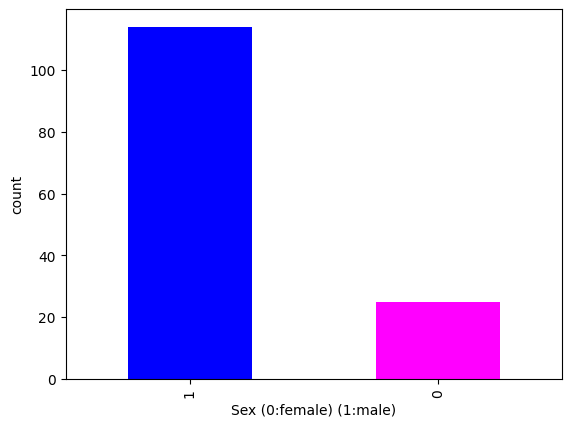

In [ ]:
# display graph of total female and male with AHD Yes
df_final.Sex[df_final.AHD_Yes==1].value_counts().plot(kind='bar',color=['blue','magenta'])
plt.xlabel("Sex (0:female) (1:male)")
plt.ylabel("count")
plt.show()

In [ ]:
# Find co-relation between all column
df_final.corr()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable,AHD_No,AHD_Yes
Age,1.000000,-0.097542,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.135337,-0.051714,-0.151684,0.045438,0.062042,-0.132264,0.104902,-0.223120,0.223120
Sex,-0.097542,1.000000,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.086398,-0.117189,-0.037990,0.089828,0.142524,-0.387396,0.326284,-0.276816,0.276816
RestBP,0.284946,-0.064456,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.027710,-0.050127,-0.083234,0.149737,0.075157,-0.139782,0.106210,-0.150825,0.150825
Chol,0.208950,-0.199915,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.070343,-0.033223,-0.016453,-0.053021,-0.095743,-0.006479,0.053100,-0.085164,0.085164
Fbs,0.118530,0.047862,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,-0.062929,0.087027,-0.060649,0.055511,0.091351,-0.073766,0.030953,-0.025264,0.025264
RestECG,0.148868,0.021647,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.122589,-0.089526,-0.102979,0.065581,0.044672,-0.028989,0.007905,-0.169202,0.169202
MaxHR,-0.393806,-0.048663,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.371989,0.159876,0.249415,0.079683,-0.159523,0.285812,-0.214326,0.417167,-0.417167
ExAng,0.091661,0.146201,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.464293,-0.266871,-0.233863,-0.093384,0.063073,-0.324082,0.300223,-0.431894,0.431894
Oldpeak,0.203805,0.102173,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.274218,-0.126339,-0.277513,0.086959,0.104635,-0.345731,0.302145,-0.424510,0.424510
Slope,0.161770,0.037533,0.117382,-0.004062,0.059894,0.133946,-0.385601,0.257748,0.577537,1.000000,0.110803,0.209528,-0.103004,-0.202807,0.064509,0.185825,-0.301252,0.217318,-0.339213,0.339213


<Axes: >

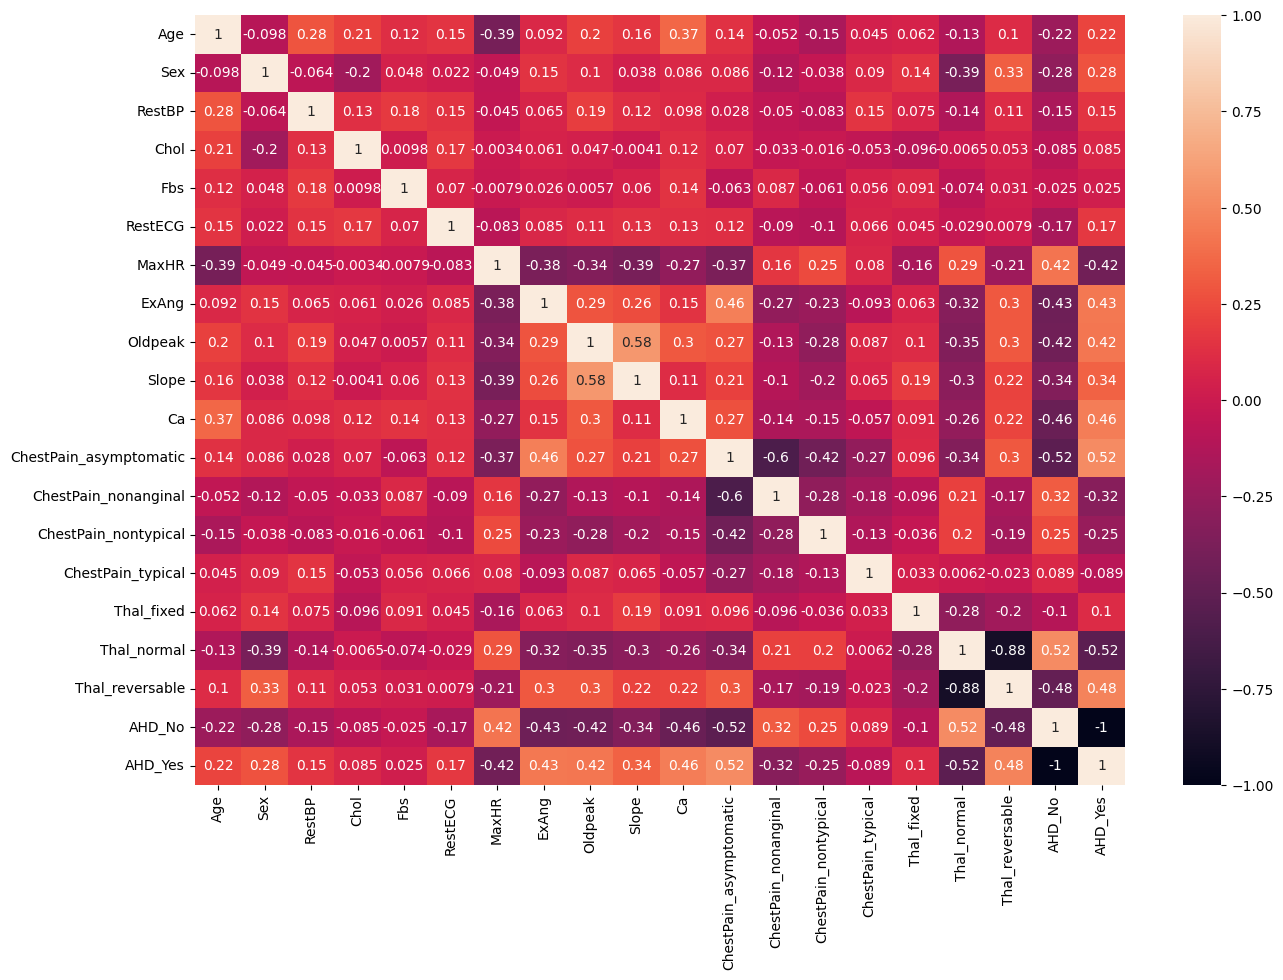

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df_final.corr(),annot=True)

In [ ]:
# The above co-relation and heatmap we can say that AHD_NO and AHD_yes are giving the same information, so removing one of them (AHD_No)
# droping AHD_No as its giving the same value as AHD_Yes
df_final = df_final.drop('AHD_No', axis = 1)
df_final.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable,AHD_Yes
0,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,False,True,True,False,False,False
1,67,1,160,286,0,2,108,1,1.5,2,3.0,True,False,False,False,False,True,False,True
2,67,1,120,229,0,2,129,1,2.6,2,2.0,True,False,False,False,False,False,True,True
3,37,1,130,250,0,0,187,0,3.5,3,0.0,False,True,False,False,False,True,False,False
4,41,0,130,204,0,2,172,0,1.4,1,0.0,False,False,True,False,False,True,False,False


In [ ]:
df_final.columns

Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_asymptomatic',
       'ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical',
       'Thal_fixed', 'Thal_normal', 'Thal_reversable', 'AHD_Yes'],
      dtype='object')

###Applying preprocessing - MinMaxScalar

In [ ]:
# Scaling all values except the target variable = AHD_Yes
from sklearn.preprocessing import MinMaxScaler
MMsc=MinMaxScaler()
features=['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_asymptomatic',
       'ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical',
       'Thal_fixed', 'Thal_normal', 'Thal_reversable']
df_final[features] = MMsc.fit_transform(df_final[features])
df_final.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable,AHD_Yes
0,0.708333,1.0,0.481132,0.244292,1.0,1.0,0.603053,0.0,0.370968,1.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,False
1,0.791667,1.0,0.622642,0.365297,0.0,1.0,0.282443,1.0,0.241935,0.5,1.000000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,True
2,0.791667,1.0,0.245283,0.235160,0.0,1.0,0.442748,1.0,0.419355,0.5,0.666667,1.0,0.0,0.0,0.0,0.0,0.0,1.0,True
3,0.166667,1.0,0.339623,0.283105,0.0,0.0,0.885496,0.0,0.564516,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,False
4,0.250000,0.0,0.339623,0.178082,0.0,1.0,0.770992,0.0,0.225806,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,False


In [ ]:
# Defining features and target
X = df_final.drop(['AHD_Yes'], axis=1)
y = df_final.AHD_Yes

In [ ]:
#splitting the data into training and testing data sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(242, 18)
(61, 18)


##<font color='green'>**Model**

###Decision Tree Classifier

In [ ]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix
dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 51)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Accuracy of Decision Tree: ",accuracy_score(y_test, y_pred_dt))
print("Precision of Decision Tree: ",precision_score(y_test, y_pred_dt))
print("Recall of Decision Tree: ",recall_score(y_test, y_pred_dt))
print("F1 score of Decision Tree: ",f1_score(y_test, y_pred_dt))
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy of Decision Tree:  0.6557377049180327
Precision of Decision Tree:  0.6071428571428571
Recall of Decision Tree:  0.6296296296296297
F1 score of Decision Tree:  0.6181818181818182
Confusion matrix: 
[[23 11]
 [10 17]]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
cm = confusion_matrix(y_test, y_pred_dt)
print('Confusion matrix ')
print(cm)
print('Accuracy Score ',accuracy_score(y_test, y_pred_dt))
print('-'*20,'Classification Report' , '-'*20)
print(classification_report(y_test,y_pred_dt))

Confusion matrix 
[[23 11]
 [10 17]]
Accuracy Score  0.6557377049180327
-------------------- Classification Report --------------------
              precision    recall  f1-score   support

       False       0.70      0.68      0.69        34
        True       0.61      0.63      0.62        27

    accuracy                           0.66        61
   macro avg       0.65      0.65      0.65        61
weighted avg       0.66      0.66      0.66        61



In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
kfold = KFold(n_splits=10, shuffle=True,random_state=10)
score = cross_val_score(dt, X, y, cv=kfold, scoring='accuracy').mean()
print(score)

0.7494623655913978


In [ ]:
print("After Cross validation accuracy:",score*100)

After Cross validation accuracy: 74.94623655913978


Hyperparameter tunning

In [ ]:
DecisionTreeClassifier?

In [ ]:
from sklearn.model_selection import GridSearchCV
DT = DecisionTreeClassifier()
# Define the parameter grid for hyperparameter tuning,
params = {'criterion' : ['gini', 'entropy','log_loss'], #The criteria for tree default is gini
          'max_depth': [3,5,7], # The maximum depth of the tree
          'splitter': ['best', 'random'], #The strategy used to choose the split at each node
          'min_samples_leaf':[1,2,5]
         }
DTm=GridSearchCV(estimator= DT,     # A sklearn model
    param_grid=params,    # A dictionary of parameter names and values
    cv=10 ,            # An integer that represents the number of k-folds
    scoring='accuracy',       # The performance measure (such as r2, precision)
    n_jobs=5,        # The number of jobs to run in parallel
    verbose=3       # Verbosity (0-3, with higher being more)
)

DTm.fit(X_train, y_train)
from sklearn.metrics import confusion_matrix, precision_score,recall_score,f1_score,accuracy_score
y_pred = DTm.predict(X_test)

# Evaluate the Decision Tree
cm=confusion_matrix(y_test,y_pred)
print("Confusion matrix \n",cm)

print("Precision: ",precision_score(y_test,y_pred))
print("Recall: ",recall_score(y_test,y_pred))
print("F1 score: ",f1_score(y_test,y_pred))
print("Accuracy: ",accuracy_score(y_test,y_pred))


# Printing the best parameters
print("Decicion Tree best parameters")
print(DTm.best_params_)

Fitting 10 folds for each of 54 candidates, totalling 540 fits
Confusion matrix 
 [[29  5]
 [ 6 21]]
Precision:  0.8076923076923077
Recall:  0.7777777777777778
F1 score:  0.7924528301886793
Accuracy:  0.819672131147541
Decicion Tree best parameters
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'splitter': 'random'}


**Display the fitted decision tree with plot_tree**

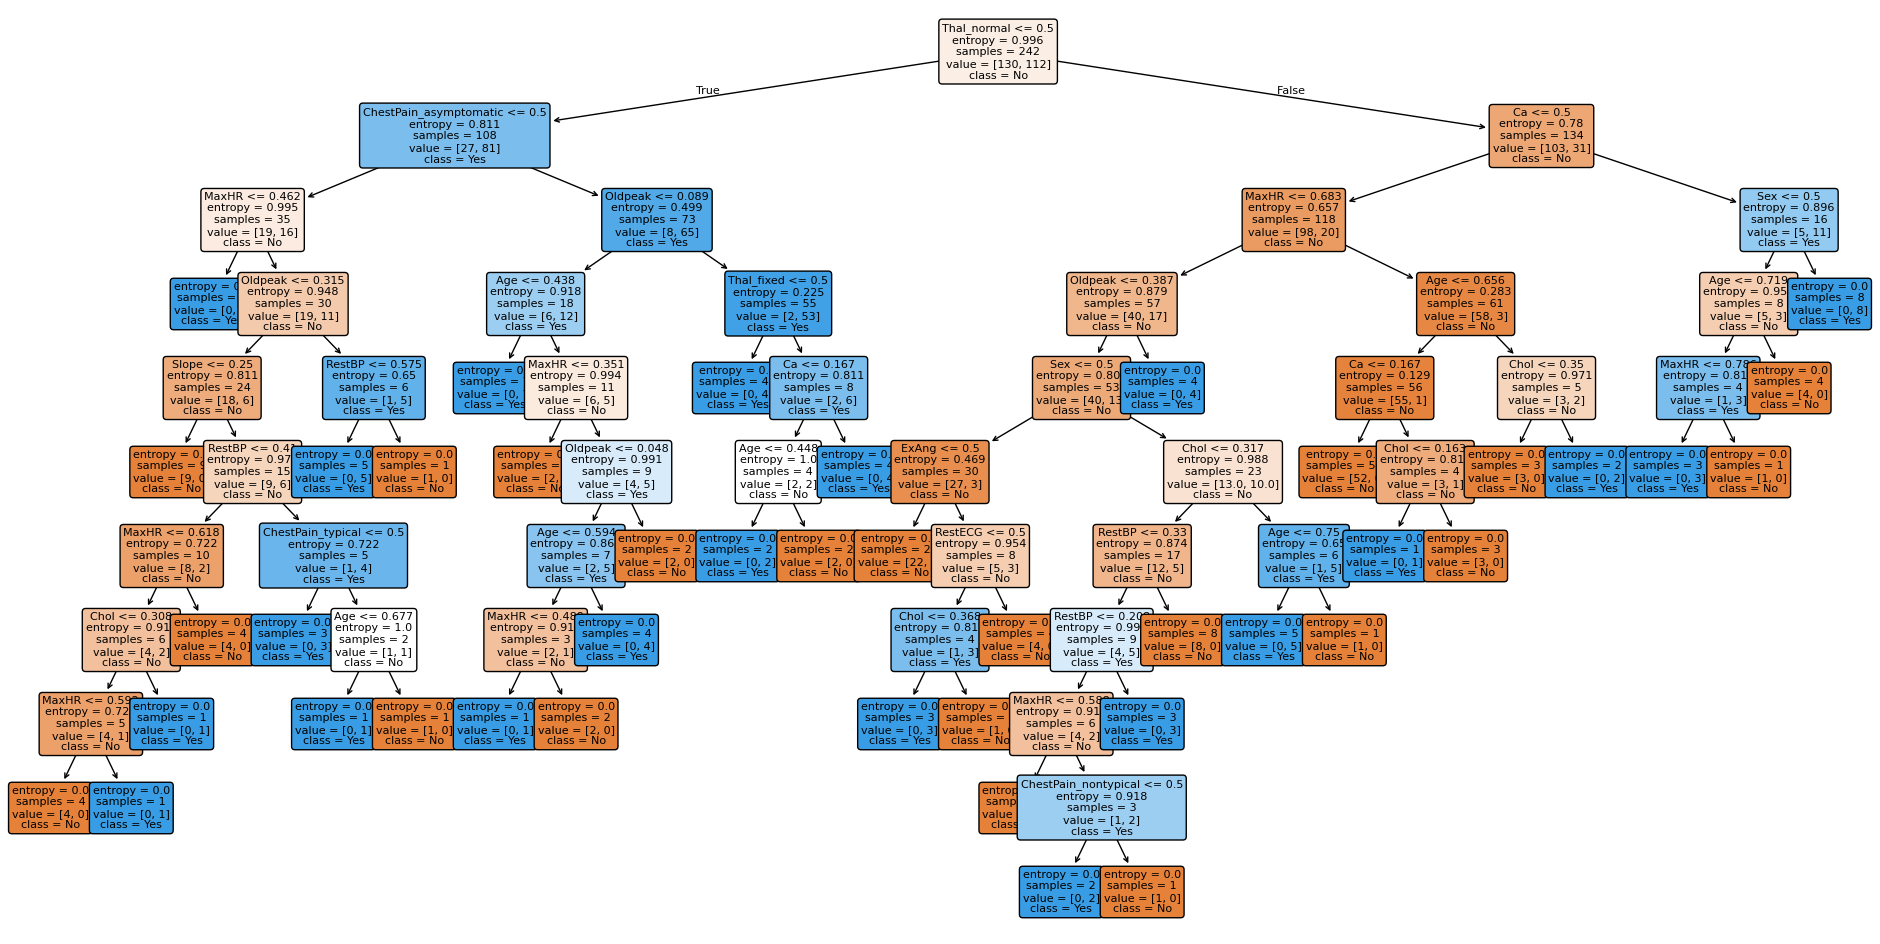

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plot_tree(
    dt,                      # use the already fitted model
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

**Display the best tuned model from GridSearchCV**

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=2,
                       splitter='random')


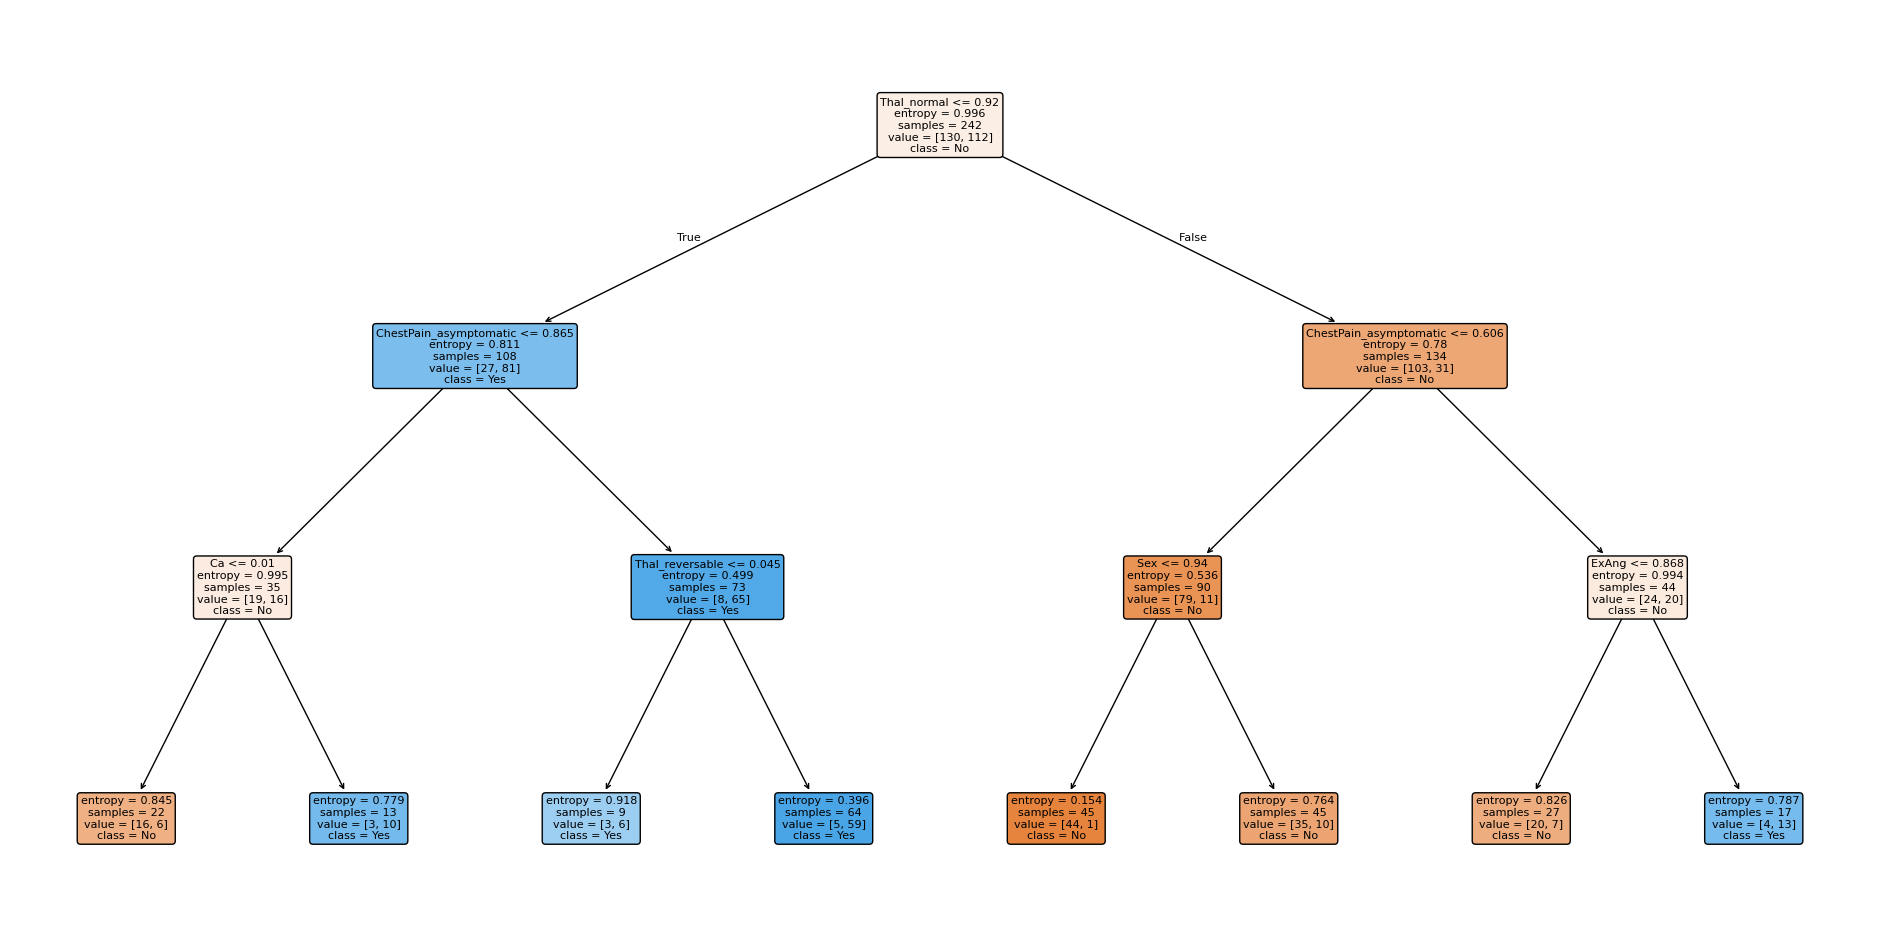

In [ ]:
best_dt = DTm.best_estimator_
print(best_dt)
plt.figure(figsize=(24, 12))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

**Graphviz output**

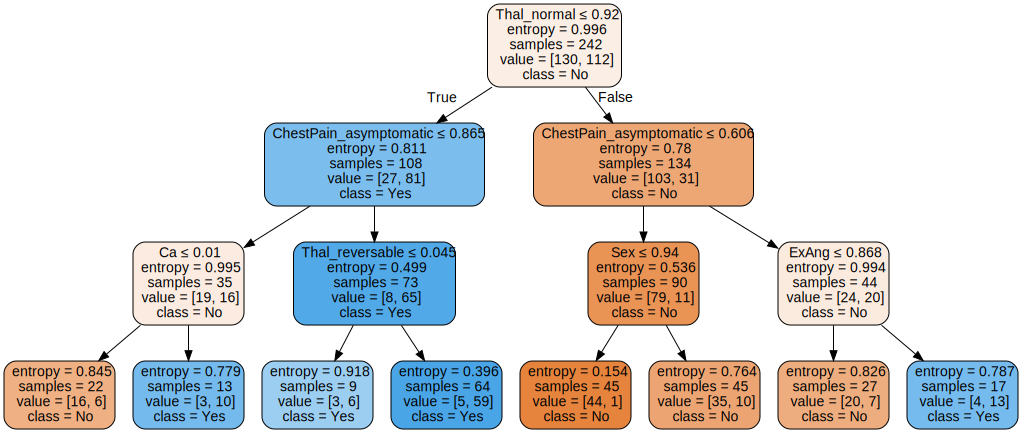

In [ ]:
import graphviz
from sklearn import tree
best_dt = DTm.best_estimator_   # or use dt if you want the earlier fitted tree

dot_data = tree.export_graphviz(
    best_dt,
    out_file=None,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

df_final.AHD_Yes

In [ ]:
DTm.classes_

array([False,  True])